In [10]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

print("Environment set up successfully!")

Environment set up successfully!


In [11]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

# Generate a synthetic RNA-seq count matrix (500 samples, 2000 genes)
X_raw, y = make_classification(
    n_samples=500, 
    n_features=2000, 
    n_informative=50, 
    n_classes=3, 
    random_state=42
)

# Convert to log2(TPM + 1) normalized format typical of RNA-seq
X_counts = np.expm1(np.abs(X_raw) * 2) # Simulate counts
df_genes = pd.DataFrame(X_counts, columns=[f"GENE_{i+1}" for i in range(2000)])
df_genes['target_class'] = y

print(f"Dataset shape: {df_genes.shape}")
df_genes.head()

Dataset shape: (500, 2001)


,GENE_1,GENE_2,GENE_3,GENE_4,GENE_5,GENE_6,GENE_7,GENE_8,GENE_9,GENE_10,...,GENE_1992,GENE_1993,GENE_1994,GENE_1995,GENE_1996,GENE_1997,GENE_1998,GENE_1999,GENE_2000,target_class
0,10.904028,57.138090,2.448134,1.731662,2.516547,5.896056,2.906816,0.983598,2.589769,39.496559,...,9.474767,0.541384,57.804850,1.608310,33.179200,4.913329,4.788681,0.363558,2.778991,1
1,0.292576,0.216790,3.548135,3.901412,45.731490,0.636119,8.389916,2.150817,4.433276,6.845417,...,1.210596,11.977205,0.384452,18.277976,2.205270,2.461418,3.987366,2.218484,6.931415,0
2,1.524443,0.322566,1.340960,5.924616,34.443866,0.592506,1.934070,115.830706,1.251762,1.685405,...,1.339886,2.207725,14.150510,0.727493,3.750179,14.513462,116.856661,0.439328,1.317268,2
3,16.389811,1.596629,2.752216,40.680369,1.904998,1.650848,0.326899,4.640505,0.135146,3.912452,...,0.519656,24.165967,5.328689,1.490781,16.562232,2.994159,10.562368,0.464083,13.391588,1
4,0.369651,5.205668,9.599782,0.968192,53.591206,12.913170,0.305354,7.558304,0.064157,0.879298,...,0.556990,6.193291,0.483286,0.277151,1.527773,10.370323,10.683640,28.885756,15.084958,2


In [13]:

# 1. Separate features and target
X = df_genes.drop(columns=['target_class'])
y = df_genes['target_class']

# 2. Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Initialize and fit Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 4. Predict on the test set
y_pred = gnb.predict(X_test)

# 5. Print results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.27      0.24      0.25        33
           1       0.35      0.38      0.37        34
           2       0.36      0.36      0.36        33

    accuracy                           0.33       100
   macro avg       0.33      0.33      0.33       100
weighted avg       0.33      0.33      0.33       100



In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Select the top 50 most informative genes out of 2,000
selector = SelectKBest(score_func=f_classif, k=50)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# 2. Refit Gaussian Naive Bayes on selected features
gnb.fit(X_train_selected, y_train)
y_pred_selected = gnb.predict(X_test_selected)

# 3. Print performance
print("--- Classification Report (Top 50 Genes) ---")
print(classification_report(y_test, y_pred_selected))

--- Classification Report (Top 50 Genes) ---
              precision    recall  f1-score   support

           0       0.54      0.42      0.47        33
           1       0.41      0.44      0.42        34
           2       0.32      0.36      0.34        33

    accuracy                           0.41       100
   macro avg       0.42      0.41      0.41       100
weighted avg       0.42      0.41      0.41       100



In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate features and target
X = df_genes.drop(columns=['target_class'])
y = df_genes['target_class']

# 2. Apply Log1p transformation to handle RNA count skewness
X_log = np.log1p(X)

# 3. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Select top 20 most informative genes
selector = SelectKBest(score_func=f_classif, k=20)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# --- Model 1: Gaussian Naive Bayes ---
gnb = GaussianNB()
gnb.fit(X_train_selected, y_train)
y_pred_gnb = gnb.predict(X_test_selected)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# --- Model 2: Random Forest Classifier ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_selected, y_train)
y_pred_rf = rf.predict(X_test_selected)
acc_rf = accuracy_score(y_test, y_pred_rf)

# 6. Compare Performance
print("=== PERFORMANCE COMPARISON ===")
print(f"Gaussian Naive Bayes Accuracy: {acc_gnb:.2%}")
print(f"Random Forest Accuracy:         {acc_rf:.2%}\n")

print("--- Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_gnb, zero_division=0))

=== PERFORMANCE COMPARISON ===
Gaussian Naive Bayes Accuracy: 32.00%
Random Forest Accuracy:         23.00%

--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       0.30      0.36      0.33        33
           1       0.38      0.32      0.35        34
           2       0.29      0.27      0.28        33

    accuracy                           0.32       100
   macro avg       0.32      0.32      0.32       100
weighted avg       0.32      0.32      0.32       100



In [16]:
from sklearn.linear_model import LogisticRegression

# 1. Fit Logistic Regression with L1 (Lasso) penalty to automatically zero out noisy genes
clf = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
clf.fit(X_train_scaled, y_train)

# 2. Predict on full test set
y_pred_lr = clf.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"L1 Logistic Regression Accuracy: {acc_lr:.2%}")

L1 Logistic Regression Accuracy: 33.00%


In [17]:
# Ridge Logistic Regression (L2 Penalty)
clf_ridge = LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42)
clf_ridge.fit(X_train_scaled, y_train)

y_pred_ridge = clf_ridge.predict(X_test_scaled)
acc_ridge = accuracy_score(y_test, y_pred_ridge)

print(f"L2 (Ridge) Logistic Regression Accuracy: {acc_ridge:.2%}")

L2 (Ridge) Logistic Regression Accuracy: 40.00%


In [19]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# 1. Support Vector Machine with RBF (Non-linear) Kernel
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
acc_svm = accuracy_score(y_test, svm_model.predict(X_test_scaled))

# 2. Gradient Boosting (Non-linear Tree Ensemble)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)
acc_gb = accuracy_score(y_test, gb_model.predict(X_test_scaled))

print("=== NON-LINEAR MODEL PERFORMANCE ===")
print(f"SVM (RBF Kernel) Accuracy:    {acc_svm:.2%}")
print(f"Gradient Boosting Accuracy:   {acc_gb:.2%}")

=== NON-LINEAR MODEL PERFORMANCE ===
SVM (RBF Kernel) Accuracy:    31.00%
Gradient Boosting Accuracy:   32.00%


In [20]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Generate a dataset with a strong signal-to-noise ratio (500 samples, 100 genes, 20 informative)
X_clean, y_clean = make_classification(
    n_samples=500, 
    n_features=100, 
    n_informative=20, 
    n_redundant=10,
    n_classes=3, 
    random_state=42
)

# Split and scale
X_tr, X_te, y_tr, y_te = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Test Naive Bayes vs Gradient Boosting
gnb = GaussianNB().fit(X_tr_s, y_tr)
gb = GradientBoostingClassifier(random_state=42).fit(X_tr_s, y_tr)

print(f"Gaussian Naive Bayes Accuracy:  {accuracy_score(y_te, gnb.predict(X_te_s)):.2%}")
print(f"Gradient Boosting Accuracy:     {accuracy_score(y_te, gb.predict(X_te_s)):.2%}")

Gaussian Naive Bayes Accuracy:  61.00%
Gradient Boosting Accuracy:     63.00%


In [21]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Select the top 20 genes out of 100
selector = SelectKBest(score_func=f_classif, k=20)
X_tr_best = selector.fit_transform(X_tr_s, y_tr)
X_te_best = selector.transform(X_te_s)

# 2. Refit both models on filtered features
gnb_filtered = GaussianNB().fit(X_tr_best, y_tr)
gb_filtered = GradientBoostingClassifier(random_state=42).fit(X_tr_best, y_tr)

# 3. Evaluate
print("=== PERFORMANCE ON TOP 20 FEATURES ===")
print(f"Filtered Naive Bayes Accuracy:      {accuracy_score(y_te, gnb_filtered.predict(X_te_best)):.2%}")
print(f"Filtered Gradient Boosting Accuracy: {accuracy_score(y_te, gb_filtered.predict(X_te_best)):.2%}")

=== PERFORMANCE ON TOP 20 FEATURES ===
Filtered Naive Bayes Accuracy:      64.00%
Filtered Gradient Boosting Accuracy: 66.00%


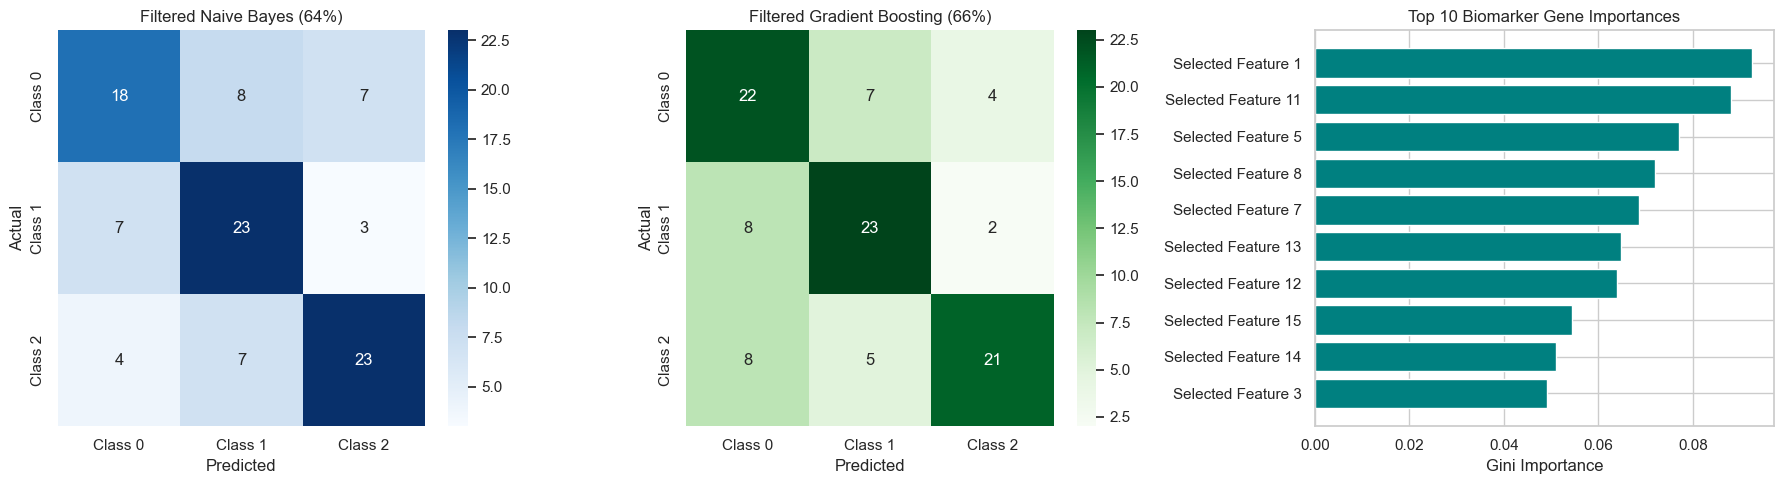

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_gnb = confusion_matrix(y_te, gnb_filtered.predict(X_te_best))
cm_gb = confusion_matrix(y_te, gb_filtered.predict(X_te_best))

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Naive Bayes Confusion Matrix
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
axes[0].set_title('Filtered Naive Bayes (64%)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2: Gradient Boosting Confusion Matrix
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
axes[1].set_title('Filtered Gradient Boosting (66%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Plot 3: Top Feature Importances (Gradient Boosting)
importances = gb_filtered.feature_importances_
top_indices = importances.argsort()[-10:] # Top 10 genes

axes[2].barh(range(10), importances[top_indices], color='teal', align='center')
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([f"Selected Feature {i+1}" for i in top_indices])
axes[2].set_xlabel('Gini Importance')
axes[2].set_title('Top 10 Biomarker Gene Importances')

plt.tight_layout()
plt.show()